# Production-Grade A/B Test Analysis
## Marketing Campaign Landing Page Creatives

**Decision:** **SHIP** the new campaign landing page, **HOLD** the current creative, or **EXTEND** the experiment?

This notebook analyzes a real e-commerce experiment that randomly assigned users to one of **two creative versions of a marketing campaign landing page**:

| Assignment | Landing page | Role |
|---|---|---|
| `control` | `old_page` | Current campaign creative |
| `treatment` | `new_page` | Proposed new campaign creative |

Outcome: binary conversion (`converted` ∈ {0, 1}).

---

## What this is (and is not)

This is **inferential experiment analysis**, not predictive machine learning.

Production experimentation platforms (Microsoft ExP, DoorDash, Eppo, Statsig, and the Kohavi et al. *Trustworthy Online Controlled Experiments* playbook) emphasize **trustworthiness gates** before effect estimation: sample-ratio mismatch (SRM), data-quality filters, practical significance, power for a pre-stated MDE, and multi-method confirmation.

There is **no model to train**, no accuracy score, no AutoML. Logistic regression is used only for **effect-size / covariate adjustment** (odds ratios). A lightweight Bayesian Beta–Binomial view is included as a **secondary cross-check**, not a replacement for the primary frequentist test.

**Important honesty constraint:** “Production-grade” means production **methodology**. It does **not** mean forcing a “win.” If the cleaned data show a null / slightly negative lift, a production system should **HOLD**, not invent significance.

### Method stack (this notebook)

1. Data acquisition + schema validation  
2. Quality cleaning (mismatches, duplicates)  
3. **Trustworthiness gate: SRM** (χ² goodness-of-fit vs 50/50)  
4. EDA (rates, Wilson CIs, time trend, country)  
5. Primary effect: two-proportion z-test + Newcombe-style CI  
6. Robustness: χ² independence, bootstrap CI  
7. Covariate-adjusted logit (odds ratios ± country)  
8. Practical significance + power / MDE  
9. Optional Bayesian P(new > old)  
10. Production decision scorecard → SHIP / HOLD / EXTEND  

## 1. Setup

In [1]:
from __future__ import annotations

import sys
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import statsmodels
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    power_proportions_2indep,
    proportion_confint,
    proportion_effectsize,
    proportions_chisquare,
    proportions_ztest,
)
from statsmodels.stats.power import NormalIndPower

try:
    from IPython.display import display
except ImportError:  # plain-script fallback

    def display(obj):  # type: ignore[misc]
        print(obj)


# Deterministic bootstrap
RNG = np.random.default_rng(42)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Pre-declared decision constants (do not change after seeing results)
ALPHA = 0.05
EXPECTED_SPLIT = 0.5  # intended 50/50 randomization
PRACTICAL_ABS_PP = 0.005  # ±0.5 pp absolute practical band around 0
MDE_ABS_PP = 0.01  # business MDE for power: +1 pp absolute
POWER_TARGET = 0.80
SRM_ALPHA = 0.001  # industry often uses strict SRM threshold (very sensitive at large n)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Kernel target name: ab-test-marketing-project")
print(f"Python:      {sys.version}")
print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"scipy:       {scipy.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"matplotlib:  {plt.matplotlib.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print()
print("Pre-declared constants:")
print(f"  ALPHA={ALPHA}, SRM_ALPHA={SRM_ALPHA}, EXPECTED_SPLIT={EXPECTED_SPLIT}")
print(f"  PRACTICAL_ABS_PP={PRACTICAL_ABS_PP}, MDE_ABS_PP={MDE_ABS_PP}, POWER_TARGET={POWER_TARGET}")

Kernel target name: ab-test-marketing-project
Python:      3.13.13 (main, Jun  2 2026, 22:27:49) [Clang 22.1.3 ]
pandas:      3.0.3
numpy:       2.5.1
scipy:       1.18.0
statsmodels: 0.14.6
matplotlib:  3.11.0
seaborn:     0.13.2
Project root: /home/ahmad/AI/AB Test Analysis for a Marketing Compaign

Pre-declared constants:
  ALPHA=0.05, SRM_ALPHA=0.001, EXPECTED_SPLIT=0.5
  PRACTICAL_ABS_PP=0.005, MDE_ABS_PP=0.01, POWER_TARGET=0.8


## 2. Data acquisition

Public Udacity DAND e-commerce A/B dataset (widely mirrored).

- `ab_data.csv`: `user_id`, `timestamp`, `group`, `landing_page`, `converted`
- `countries.csv`: `user_id`, `country` (`US` / `CA` / `UK`)

Primary path: GitHub raw URLs. Fallback: git clone.

In [2]:
AB_URL = (
    "https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/"
    "master/ab_data.csv"
)
COUNTRIES_URL = (
    "https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/"
    "master/countries.csv"
)
REPO_URL = "https://github.com/jemc36/Udacity-DAND-AB-test-ecommerce"
CLONE_DIR = DATA_DIR / "Udacity-DAND-AB-test-ecommerce"


def _load_csv(url: str, cache_name: str) -> pd.DataFrame:
    df = pd.read_csv(url)
    df.to_csv(DATA_DIR / cache_name, index=False)
    return df


try:
    ab_data = _load_csv(AB_URL, "ab_data.csv")
    countries = _load_csv(COUNTRIES_URL, "countries.csv")
    load_path_used = f"raw GitHub URLs\n  ab: {AB_URL}\n  countries: {COUNTRIES_URL}"
except Exception as url_err:
    print(f"URL load failed ({type(url_err).__name__}: {url_err})")
    print("Falling back to git clone...")
    if not (CLONE_DIR / "ab_data.csv").exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(CLONE_DIR)], check=True)
    ab_data = pd.read_csv(CLONE_DIR / "ab_data.csv")
    countries = pd.read_csv(CLONE_DIR / "countries.csv")
    load_path_used = f"local clone at {CLONE_DIR}"

print("Data load path used:")
print(load_path_used)
print()
print("ab_data shape:", ab_data.shape)
print("countries shape:", countries.shape)
display(ab_data.head())
display(countries.head())

# Schema validation (production gate)
required_ab = {"user_id", "timestamp", "group", "landing_page", "converted"}
required_cty = {"user_id", "country"}
missing_ab = required_ab - set(ab_data.columns)
missing_cty = required_cty - set(countries.columns)
assert not missing_ab, f"ab_data missing columns: {missing_ab}"
assert not missing_cty, f"countries missing columns: {missing_cty}"
assert set(ab_data["group"].dropna().unique()) <= {"control", "treatment"}
assert set(ab_data["landing_page"].dropna().unique()) <= {"old_page", "new_page"}
assert set(ab_data["converted"].dropna().unique()) <= {0, 1}
print("Schema validation: PASS")
print()
print(ab_data.dtypes.to_frame("dtype").join(ab_data.isna().sum().rename("n_missing")))
print()
print("Raw group counts:\n", ab_data["group"].value_counts())
print("Raw landing_page counts:\n", ab_data["landing_page"].value_counts())
print("Raw conversion rate:", f"{ab_data['converted'].mean():.6f}")

Data load path used:
raw GitHub URLs
  ab: https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/master/ab_data.csv
  countries: https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/master/countries.csv

ab_data shape: (294478, 5)
countries shape: (290584, 2)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


Schema validation: PASS

              dtype  n_missing
user_id       int64          0
timestamp       str          0
group           str          0
landing_page    str          0
converted     int64          0

Raw group counts:
 group
treatment    147276
control      147202
Name: count, dtype: int64
Raw landing_page counts:
 landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64
Raw conversion rate: 0.119659


## Part 1 — Data cleaning (exposure integrity)

Production systems refuse to estimate treatment effects on rows with **unknown exposure**.

**Rules (fixed before estimation):**
1. Keep only consistent rows: `(control, old_page)` or `(treatment, new_page)`.
2. Keep one row per `user_id` (`keep='first'`).

This dataset’s intentional quality issue makes cleaning a first-class section, not a footnote.

In [3]:
n_before = len(ab_data)
print(f"Rows before cleaning: {n_before:,}")

consistent = (
    ((ab_data["group"] == "control") & (ab_data["landing_page"] == "old_page"))
    | ((ab_data["group"] == "treatment") & (ab_data["landing_page"] == "new_page"))
)
mismatched = ab_data.loc[~consistent].copy()
n_mismatch = len(mismatched)
print(f"Mismatched rows: {n_mismatch:,} ({n_mismatch / n_before:.2%} of raw)")
display(
    mismatched.groupby(["group", "landing_page"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
display(mismatched.head(8))

ab_clean = ab_data.loc[consistent].copy()
n_after_mismatch = len(ab_clean)
print(f"Rows after mismatch drop: {n_after_mismatch:,}")

dup_mask = ab_clean["user_id"].duplicated(keep=False)
print(f"Rows in duplicate user_id groups: {int(dup_mask.sum()):,}")
print(f"Distinct duplicated user_ids: {ab_clean.loc[dup_mask, 'user_id'].nunique():,}")
display(ab_clean.loc[dup_mask].sort_values("user_id"))

ab_clean = ab_clean.drop_duplicates(subset="user_id", keep="first").copy()
n_after_dedup = len(ab_clean)
assert ab_clean["user_id"].is_unique

cleaning_summary = pd.DataFrame(
    {
        "stage": ["raw", "after_mismatch_drop", "after_dedup"],
        "n_rows": [n_before, n_after_mismatch, n_after_dedup],
    }
)
cleaning_summary["delta"] = cleaning_summary["n_rows"].diff().fillna(0).astype(int)
display(cleaning_summary)
display(pd.crosstab(ab_clean["group"], ab_clean["landing_page"]))
print("Final arm sizes:\n", ab_clean["group"].value_counts().sort_index())

Rows before cleaning: 294,478
Mismatched rows: 3,893 (1.32% of raw)


,group,landing_page,n
0,control,new_page,1928
1,treatment,old_page,1965


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
490,808613,2017-01-10 21:44:01.292755,control,new_page,0
685,666385,2017-01-23 08:11:54.823806,treatment,old_page,0
713,748761,2017-01-10 15:47:44.445196,treatment,old_page,0


Rows after mismatch drop: 290,585


Rows in duplicate user_id groups: 2
Distinct duplicated user_ids: 1


,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


,stage,n_rows,delta
0,raw,294478,0
1,after_mismatch_drop,290585,-3893
2,after_dedup,290584,-1


landing_page,new_page,old_page
group,,
control,0,145274
treatment,145310,0


Final arm sizes:
 group
control      145274
treatment    145310
Name: count, dtype: int64


## Part 1b — Trustworthiness gate: Sample Ratio Mismatch (SRM)

**Why this matters (industry standard):** Microsoft ExP, DoorDash, Eppo, and others treat **SRM** as a hard trustworthiness check. If the observed control/treatment counts deviate from the intended allocation more than chance allows, **randomization or logging is compromised** and effect estimates should not be trusted until diagnosed.

Detection: χ² goodness-of-fit of observed arm counts against expected 50/50.

At very large \(n\), even tiny imbalances are “significant.” We report the p-value **and** the absolute imbalance. A severe SRM (tiny p + large imbalance) is a red flag; a tiny imbalance with large \(n\) can still be operationally fine.

In [4]:
n_control = int((ab_clean["group"] == "control").sum())
n_treatment = int((ab_clean["group"] == "treatment").sum())
n_total = n_control + n_treatment
obs = np.array([n_control, n_treatment], dtype=float)
exp = np.array([EXPECTED_SPLIT * n_total, (1 - EXPECTED_SPLIT) * n_total], dtype=float)
srm_chi2, srm_p = stats.chisquare(f_obs=obs, f_exp=exp)
obs_share_treat = n_treatment / n_total
abs_imbalance_pp = abs(obs_share_treat - EXPECTED_SPLIT) * 100

srm_pass = srm_p >= SRM_ALPHA  # strict threshold; still inspect magnitude
# Production nuance: also require absolute imbalance not extreme
srm_severe = (srm_p < SRM_ALPHA) and (abs_imbalance_pp > 0.5)

print("=== Sample Ratio Mismatch (SRM) ===")
print(f"Observed: control={n_control:,}, treatment={n_treatment:,}, total={n_total:,}")
print(f"Expected split: {EXPECTED_SPLIT:.0%} / {1 - EXPECTED_SPLIT:.0%}")
print(f"Observed treatment share: {obs_share_treat:.6%}")
print(f"Absolute imbalance: {abs_imbalance_pp:.4f} percentage points of traffic")
print(f"χ² = {srm_chi2:.6f}, p = {srm_p:.6g}")
print(f"SRM gate (p >= {SRM_ALPHA}): {'PASS' if srm_pass else 'FLAG'}")
print(f"Severe SRM (flag + >0.5pp imbalance): {srm_severe}")
if abs_imbalance_pp < 0.1:
    print("Magnitude: imbalance is tiny — large-n χ² can flag noise; effect analysis remains usable.")
elif srm_severe:
    print("Magnitude: SEVERE — diagnose instrumentation before shipping on this test.")
else:
    print("Magnitude: mild/moderate — document and proceed with caution.")

=== Sample Ratio Mismatch (SRM) ===
Observed: control=145,274, treatment=145,310, total=290,584
Expected split: 50% / 50%
Observed treatment share: 50.006194%
Absolute imbalance: 0.0062 percentage points of traffic
χ² = 0.004460, p = 0.946754
SRM gate (p >= 0.001): PASS
Severe SRM (flag + >0.5pp imbalance): False
Magnitude: imbalance is tiny — large-n χ² can flag noise; effect analysis remains usable.


## Part 2 — EDA on cleaned data

Primary **OEC** (Overall Evaluation Criterion) for this experiment: **conversion rate**.
Wilson score intervals are preferred over plain normal intervals for proportions in production dashboards.

,group,n,conversions,rate,rate_pct
0,control,145274,17489,0.120386,12.0386
1,treatment,145310,17264,0.118808,11.8808


Overall conversion: 11.9597% (n=290,584)
Control:   p=0.120386, n=145,274, conv=17,489
Treatment: p=0.118808, n=145,310, conv=17,264
Diff (new−old): -0.001578 (-0.1578 pp), relative -1.3110%
Wilson 95% CI control:   [0.118723, 0.122070]
Wilson 95% CI treatment: [0.117154, 0.120482]


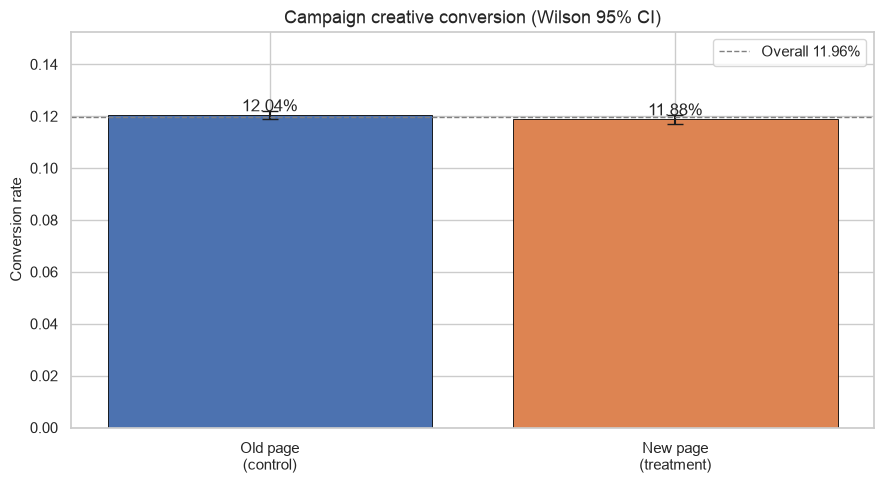

In [5]:
overall_rate = ab_clean["converted"].mean()
by_group = (
    ab_clean.groupby("group", observed=True)
    .agg(n=("converted", "size"), conversions=("converted", "sum"), rate=("converted", "mean"))
    .reset_index()
)
display(by_group.assign(rate_pct=lambda d: (100 * d["rate"]).round(4)))

ctrl = by_group.loc[by_group["group"] == "control"].iloc[0]
trt = by_group.loc[by_group["group"] == "treatment"].iloc[0]
p_control = float(ctrl["rate"])
p_treatment = float(trt["rate"])
conv_control = int(ctrl["conversions"])
conv_treatment = int(trt["conversions"])
# reaffirm n from by_group (should match SRM counts)
n_control = int(ctrl["n"])
n_treatment = int(trt["n"])
abs_diff = p_treatment - p_control
rel_diff = abs_diff / p_control if p_control else np.nan

print(f"Overall conversion: {overall_rate:.4%} (n={len(ab_clean):,})")
print(f"Control:   p={p_control:.6f}, n={n_control:,}, conv={conv_control:,}")
print(f"Treatment: p={p_treatment:.6f}, n={n_treatment:,}, conv={conv_treatment:,}")
print(f"Diff (new−old): {abs_diff:.6f} ({abs_diff * 100:.4f} pp), relative {rel_diff:.4%}")

# Wilson CIs for each arm
ci_c = proportion_confint(conv_control, n_control, alpha=ALPHA, method="wilson")
ci_t = proportion_confint(conv_treatment, n_treatment, alpha=ALPHA, method="wilson")
print(f"Wilson 95% CI control:   [{ci_c[0]:.6f}, {ci_c[1]:.6f}]")
print(f"Wilson 95% CI treatment: [{ci_t[0]:.6f}, {ci_t[1]:.6f}]")

plot_df = pd.DataFrame(
    {
        "creative": ["Old page\n(control)", "New page\n(treatment)"],
        "rate": [p_control, p_treatment],
        "ci_low": [ci_c[0], ci_t[0]],
        "ci_high": [ci_c[1], ci_t[1]],
    }
)
plot_df["yerr_low"] = plot_df["rate"] - plot_df["ci_low"]
plot_df["yerr_high"] = plot_df["ci_high"] - plot_df["rate"]

fig, ax = plt.subplots()
bars = ax.bar(
    plot_df["creative"],
    plot_df["rate"],
    yerr=[plot_df["yerr_low"], plot_df["yerr_high"]],
    capsize=6,
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    linewidth=0.6,
)
ax.axhline(overall_rate, color="gray", ls="--", lw=1, label=f"Overall {overall_rate:.2%}")
ax.set_ylabel("Conversion rate")
ax.set_title("Campaign creative conversion (Wilson 95% CI)")
ax.set_ylim(0, max(plot_df["ci_high"]) * 1.25)
ax.legend(loc="upper right")
for bar, rate in zip(bars, plot_df["rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0015, f"{rate:.2%}", ha="center")
plt.tight_layout()
plt.show()

### Time trend (novelty / drift check)

Production risk: novelty effects or non-stationarity. Plot daily conversion by arm.

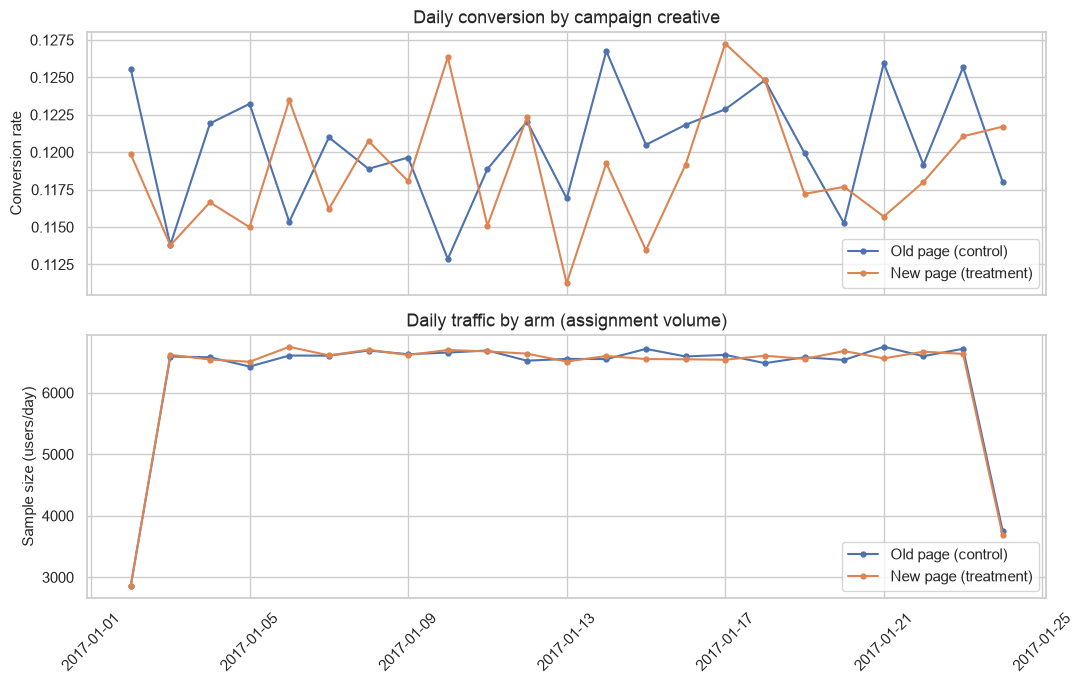

Date range: 2017-01-02 13:42:05.378582 → 2017-01-24 13:41:54.460509
Distinct days: 23


In [6]:
ab_clean = ab_clean.copy()
ab_clean["timestamp"] = pd.to_datetime(ab_clean["timestamp"])
ab_clean["date"] = ab_clean["timestamp"].dt.date

daily = (
    ab_clean.groupby(["date", "group"], observed=True)["converted"]
    .agg(n="size", rate="mean")
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for group, color, label in [
    ("control", "#4C72B0", "Old page (control)"),
    ("treatment", "#DD8452", "New page (treatment)"),
]:
    g = daily.loc[daily["group"] == group].sort_values("date")
    axes[0].plot(g["date"], g["rate"], marker="o", ms=3.5, color=color, label=label)
    axes[1].plot(g["date"], g["n"], marker="o", ms=3.5, color=color, label=label)
axes[0].set_ylabel("Conversion rate")
axes[0].set_title("Daily conversion by campaign creative")
axes[0].legend()
axes[1].set_ylabel("Sample size (users/day)")
axes[1].set_title("Daily traffic by arm (assignment volume)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Date range:", ab_clean["timestamp"].min(), "→", ab_clean["timestamp"].max())
print("Distinct days:", ab_clean["date"].nunique())

### Country merge and segment rates

Segments are diagnostic. Segment-level tests later use multiplicity control.

Merge loss: 0 rows


,country,n,rate,rate_pct
0,CA,14499,0.115318,11.5318
1,UK,72466,0.120594,12.0594
2,US,203619,0.119547,11.9547


,country,group,n,rate,rate_pct
0,CA,control,7198,0.118783,11.8783
1,CA,treatment,7301,0.111902,11.1902
2,UK,control,36360,0.120022,12.0022
3,UK,treatment,36106,0.121171,12.1171
4,US,control,101716,0.120630,12.0630
5,US,treatment,101903,0.118466,11.8466


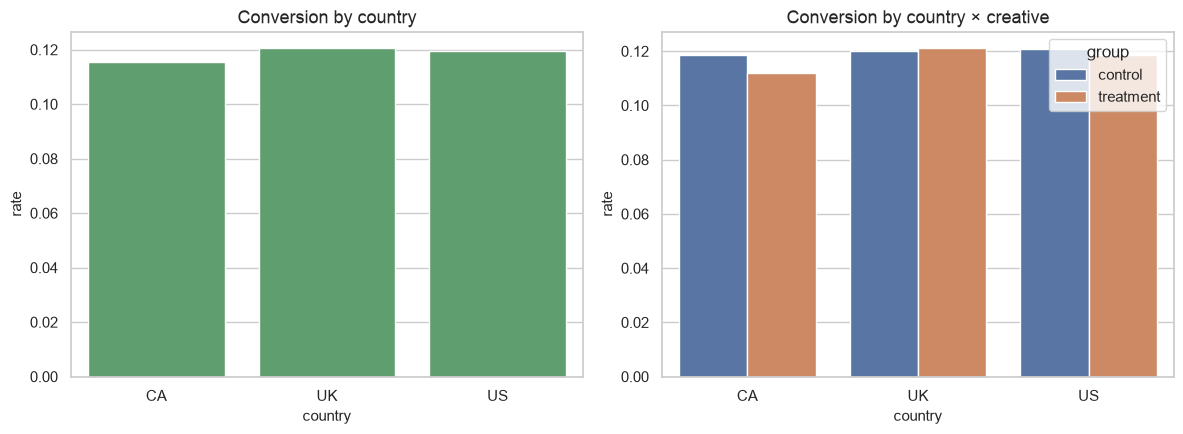

In [7]:
n_before_merge = len(ab_clean)
df = ab_clean.merge(countries, on="user_id", how="inner")
n_after_merge = len(df)
print(f"Merge loss: {n_before_merge - n_after_merge:,} rows")
df["ab_page"] = (df["group"] == "treatment").astype(int)

by_country = (
    df.groupby("country", observed=True)
    .agg(n=("converted", "size"), rate=("converted", "mean"))
    .reset_index()
)
by_country_group = (
    df.groupby(["country", "group"], observed=True)
    .agg(n=("converted", "size"), rate=("converted", "mean"))
    .reset_index()
)
display(by_country.assign(rate_pct=lambda d: (100 * d["rate"]).round(4)))
display(by_country_group.assign(rate_pct=lambda d: (100 * d["rate"]).round(4)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=by_country, x="country", y="rate", ax=axes[0], color="#55A868")
axes[0].set_title("Conversion by country")
sns.barplot(data=by_country_group, x="country", y="rate", hue="group", ax=axes[1])
axes[1].set_title("Conversion by country × creative")
plt.tight_layout()
plt.show()

## Part 3 — Primary hypothesis test (two-proportion z-test)

**Plain language**
- \(H_0\): new and old campaign creatives convert equally.
- \(H_1\): they differ (two-sided).

**Why two-sided?** Production default when direction was not hard-locked as a one-sided product claim before launch. Prevents post-hoc one-sided p-hacking.

Formally: \(H_0: p_{\text{new}} - p_{\text{old}} = 0\).

In [8]:
count = np.array([conv_treatment, conv_control], dtype=float)
nobs = np.array([n_treatment, n_control], dtype=float)

zstat, pval = proportions_ztest(count, nobs, alternative="two-sided")
ci_low, ci_high = confint_proportions_2indep(
    count1=conv_treatment,
    nobs1=n_treatment,
    count2=conv_control,
    nobs2=n_control,
    compare="diff",
    alpha=ALPHA,
)

# χ² cross-check (equivalent in large samples for 2x2)
chi2stat, chi2_p, chi2_table = proportions_chisquare(count, nobs)

print("=== Primary: two-proportion z-test ===")
print(f"p_new={p_treatment:.6f}, p_old={p_control:.6f}, diff={abs_diff:.6f}")
print(f"z={zstat:.6f}, p={pval:.6f}")
print(f"95% CI for (p_new − p_old): [{ci_low:.6f}, {ci_high:.6f}]")
print()
print("=== Cross-check: proportions χ² ===")
print(f"χ²={chi2stat:.6f}, p={chi2_p:.6f}")
print("Table (successes, failures) by [treatment, control]:")
print(chi2_table)

significant = pval < ALPHA
decision_h0 = "REJECT H0" if significant else "FAIL TO REJECT H0"
print()
print(f"Decision at α={ALPHA}: {decision_h0}")
if ci_low <= 0 <= ci_high:
    print("CI includes 0 → compatible with no true lift (or a very small one).")
else:
    print("CI excludes 0 → nonzero difference supported at this confidence level.")

# Practical significance band
in_practical_null = abs(abs_diff) < PRACTICAL_ABS_PP
ci_inside_practical = (ci_low > -PRACTICAL_ABS_PP) and (ci_high < PRACTICAL_ABS_PP)
print()
print(f"Practical band: ±{PRACTICAL_ABS_PP * 100:.2f} pp absolute")
print(f"Point estimate inside practical null band: {in_practical_null}")
print(f"Entire 95% CI inside practical null band: {ci_inside_practical}")

=== Primary: two-proportion z-test ===
p_new=0.118808, p_old=0.120386, diff=-0.001578
z=-1.310924, p=0.189883
95% CI for (p_new − p_old): [-0.003938, 0.000781]

=== Cross-check: proportions χ² ===
χ²=1.718522, p=0.189883
Table (successes, failures) by [treatment, control]:
(array([[ 17264., 128046.],
       [ 17489., 127785.]]), array([[ 17378.65274757, 127931.34725243],
       [ 17374.34725243, 127899.65274757]]))

Decision at α=0.05: FAIL TO REJECT H0
CI includes 0 → compatible with no true lift (or a very small one).

Practical band: ±0.50 pp absolute
Point estimate inside practical null band: True
Entire 95% CI inside practical null band: True


### Robustness: nonparametric bootstrap CI for the difference

Resample users within arms to get a percentile CI for \(p_{\text{new}} - p_{\text{old}}\). Should agree closely with the analytic CI at this sample size.

Bootstrap mean diff: -0.001578
Bootstrap 95% percentile CI: [-0.003973, 0.000769]
Analytic 95% CI:            [-0.003938, 0.000781]


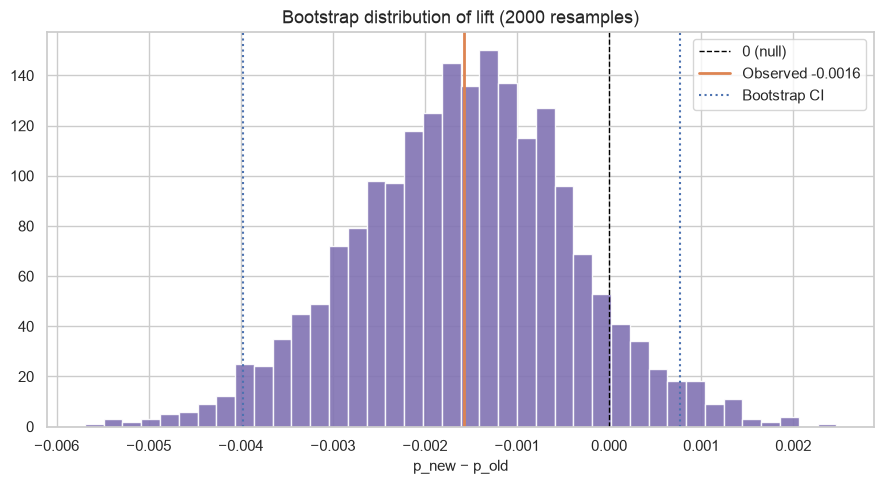

In [9]:
y_c = ab_clean.loc[ab_clean["group"] == "control", "converted"].to_numpy()
y_t = ab_clean.loc[ab_clean["group"] == "treatment", "converted"].to_numpy()

n_boot = 2000
boot_diffs = np.empty(n_boot)
for i in range(n_boot):
    bc = RNG.choice(y_c, size=y_c.size, replace=True)
    bt = RNG.choice(y_t, size=y_t.size, replace=True)
    boot_diffs[i] = bt.mean() - bc.mean()

boot_ci = np.quantile(boot_diffs, [ALPHA / 2, 1 - ALPHA / 2])
print(f"Bootstrap mean diff: {boot_diffs.mean():.6f}")
print(f"Bootstrap 95% percentile CI: [{boot_ci[0]:.6f}, {boot_ci[1]:.6f}]")
print(f"Analytic 95% CI:            [{ci_low:.6f}, {ci_high:.6f}]")

fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=40, color="#8172B3", edgecolor="white", alpha=0.9)
ax.axvline(0, color="black", ls="--", lw=1, label="0 (null)")
ax.axvline(abs_diff, color="#DD8452", lw=2, label=f"Observed {abs_diff:.4f}")
ax.axvline(boot_ci[0], color="#4C72B0", ls=":", label="Bootstrap CI")
ax.axvline(boot_ci[1], color="#4C72B0", ls=":")
ax.set_xlabel("p_new − p_old")
ax.set_title(f"Bootstrap distribution of lift ({n_boot} resamples)")
ax.legend()
plt.tight_layout()
plt.show()

## Part 4 — Logistic regression (effect size + country adjustment)

Report **odds ratios**, not accuracy. Models:
1. `converted ~ ab_page`
2. `converted ~ ab_page + C(country)`
3. `converted ~ ab_page * C(country)` (heterogeneity check)

In [10]:
def odds_ratio_table(result) -> pd.DataFrame:
    conf = result.conf_int()
    conf.columns = ["lo", "hi"]
    return pd.DataFrame(
        {
            "coef": result.params,
            "OR": np.exp(result.params),
            "OR_ci_low": np.exp(conf["lo"]),
            "OR_ci_high": np.exp(conf["hi"]),
            "pvalue": result.pvalues,
        }
    )


m1 = smf.logit("converted ~ ab_page", data=df).fit(disp=False)
m2 = smf.logit("converted ~ ab_page + C(country)", data=df).fit(disp=False)
m3 = smf.logit("converted ~ ab_page * C(country)", data=df).fit(disp=False)

or1, or2, or3 = odds_ratio_table(m1), odds_ratio_table(m2), odds_ratio_table(m3)
print("=== Model 1: converted ~ ab_page ===")
display(or1)
print(m1.summary().tables[1])
print()
print("=== Model 2: converted ~ ab_page + C(country) ===")
display(or2)
print(m2.summary().tables[1])
print()
print("=== Model 3: interaction ===")
display(or3)

or_ab_m1 = float(or1.loc["ab_page", "OR"])
or_ab_m2 = float(or2.loc["ab_page", "OR"])
pval_ab_m2 = float(or2.loc["ab_page", "pvalue"])
interaction_terms = [t for t in or3.index if ":" in t]
min_inter_p = float(or3.loc[interaction_terms, "pvalue"].min()) if interaction_terms else np.nan
print()
print("ab_page OR comparison:")
display(
    pd.DataFrame(
        {
            "model": ["unadjusted", "country-adjusted", "interaction main ab_page"],
            "OR": [or_ab_m1, or_ab_m2, float(or3.loc["ab_page", "OR"])],
            "pvalue": [
                float(or1.loc["ab_page", "pvalue"]),
                pval_ab_m2,
                float(or3.loc["ab_page", "pvalue"]),
            ],
        }
    )
)
print(f"Min interaction p-value: {min_inter_p:.4f}")

=== Model 1: converted ~ ab_page ===


,coef,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-1.988777,0.136863,0.134717,0.139043,0.000000
ab_page,-0.014989,0.985123,0.963291,1.007449,0.189886


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9888      0.008   -246.669      0.000      -2.005      -1.973
ab_page       -0.0150      0.011     -1.311      0.190      -0.037       0.007

=== Model 2: converted ~ ab_page + C(country) ===


,coef,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-2.030029,0.131332,0.124654,0.138367,0.000000
C(country)[T.UK],0.050640,1.051944,0.995003,1.112144,0.074500
C(country)[T.US],0.040757,1.041599,0.988138,1.097953,0.129501
ab_page,-0.014943,0.985168,0.963335,1.007495,0.191245


                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.0300      0.027    -76.249      0.000      -2.082      -1.978
C(country)[T.UK]     0.0506      0.028      1.784      0.074      -0.005       0.106
C(country)[T.US]     0.0408      0.027      1.516      0.130      -0.012       0.093
ab_page             -0.0149      0.011     -1.307      0.191      -0.037       0.007

=== Model 3: interaction ===


,coef,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-2.004006,0.134794,0.125505,0.144771,0.000000
C(country)[T.UK],0.011784,1.011854,0.935839,1.094042,0.767429
C(country)[T.US],0.017528,1.017682,0.945230,1.095689,0.641822
ab_page,-0.067448,0.934776,0.844176,1.035099,0.194724
ab_page:C(country)[T.UK],0.078282,1.081428,0.967501,1.208770,0.168119
ab_page:C(country)[T.US],0.046885,1.048001,0.943160,1.164496,0.383311



ab_page OR comparison:


,model,OR,pvalue
0,unadjusted,0.985123,0.189886
1,country-adjusted,0.985168,0.191245
2,interaction main ab_page,0.934776,0.194724


Min interaction p-value: 0.1681


### Segment tests with multiplicity control

Per-country two-proportion tests + Benjamini–Hochberg FDR (production-safe for exploratory segments).

In [11]:
segment_rows = []
for country, g in df.groupby("country", observed=True):
    yc = g.loc[g["group"] == "control", "converted"]
    yt = g.loc[g["group"] == "treatment", "converted"]
    c = np.array([yt.sum(), yc.sum()], dtype=float)
    n = np.array([yt.shape[0], yc.shape[0]], dtype=float)
    z_s, p_s = proportions_ztest(c, n, alternative="two-sided")
    segment_rows.append(
        {
            "country": country,
            "n_control": int(n[1]),
            "n_treatment": int(n[0]),
            "p_control": float(yc.mean()),
            "p_treatment": float(yt.mean()),
            "diff": float(yt.mean() - yc.mean()),
            "z": float(z_s),
            "pvalue_raw": float(p_s),
        }
    )
seg = pd.DataFrame(segment_rows).sort_values("country")
rej, p_adj, _, _ = multipletests(seg["pvalue_raw"], alpha=ALPHA, method="fdr_bh")
seg["pvalue_fdr_bh"] = p_adj
seg["sig_fdr_bh"] = rej
display(seg)

,country,n_control,n_treatment,p_control,p_treatment,diff,z,pvalue_raw,pvalue_fdr_bh,sig_fdr_bh
0,CA,7198,7301,0.118783,0.111902,-0.006881,-1.296900,0.194666,0.291998,False
1,UK,36360,36106,0.120022,0.121171,0.001149,0.474891,0.634865,0.634865,False
2,US,101716,101903,0.120630,0.118466,-0.002164,-1.505193,0.132274,0.291998,False


## Part 5 — Power, MDE, and power curve

Answer “should we extend?” with numbers:
- Power for the **observed** effect (usually low if effect is tiny)
- Power for a business **MDE** of +1 pp absolute
- Required n/arm for 80% power at that MDE
- Power curve vs sample size

=== Observed effect power ===
Cohen h=-0.004864
n/arm for 80% power @ observed effect: 663,574
Achieved power @ observed effect: 0.2587

=== MDE = +1.00 pp absolute ===
n/arm for 80% power @ MDE: 17,209
Actual min arm n: 145,274
Achieved power @ MDE: 1.0000
Underpowered for MDE: False


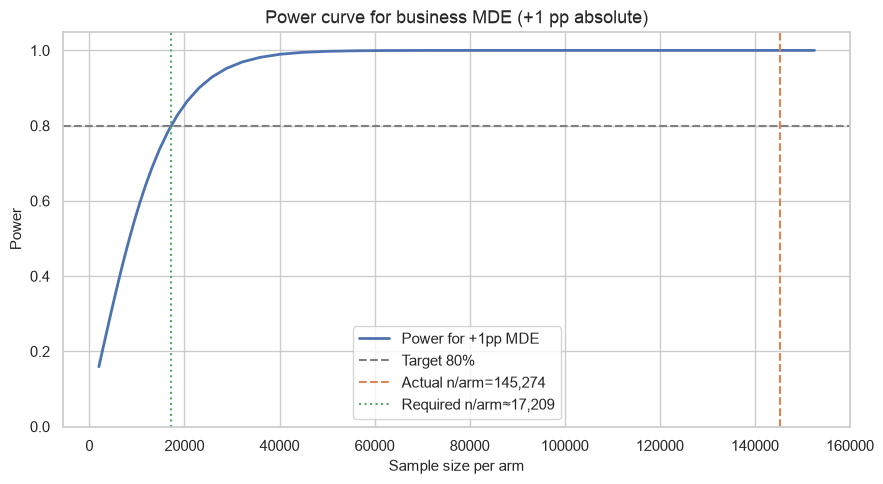

In [12]:
es_obs = proportion_effectsize(p_treatment, p_control)
if abs(es_obs) < 1e-12:
    n_for_obs = np.inf
else:
    n_for_obs = NormalIndPower().solve_power(
        effect_size=abs(es_obs),
        alpha=ALPHA,
        power=POWER_TARGET,
        ratio=1.0,
        alternative="two-sided",
    )

pwr_obs = power_proportions_2indep(
    diff=p_treatment - p_control,
    prop2=p_control,
    nobs1=n_treatment,
    ratio=n_control / n_treatment,
    alpha=ALPHA,
    alternative="two-sided",
    return_results=True,
)

p_mde = p_control + MDE_ABS_PP
es_mde = proportion_effectsize(p_mde, p_control)
n_for_mde = NormalIndPower().solve_power(
    effect_size=es_mde,
    alpha=ALPHA,
    power=POWER_TARGET,
    ratio=1.0,
    alternative="two-sided",
)
pwr_mde = power_proportions_2indep(
    diff=MDE_ABS_PP,
    prop2=p_control,
    nobs1=n_treatment,
    ratio=n_control / n_treatment,
    alpha=ALPHA,
    alternative="two-sided",
    return_results=True,
)
actual_n_per_arm = min(n_control, n_treatment)
underpowered_for_mde = pwr_mde.power < POWER_TARGET

print("=== Observed effect power ===")
print(f"Cohen h={es_obs:.6f}")
print(f"n/arm for {POWER_TARGET:.0%} power @ observed effect: {n_for_obs:,.0f}")
print(f"Achieved power @ observed effect: {pwr_obs.power:.4f}")
print()
print(f"=== MDE = +{MDE_ABS_PP * 100:.2f} pp absolute ===")
print(f"n/arm for {POWER_TARGET:.0%} power @ MDE: {n_for_mde:,.0f}")
print(f"Actual min arm n: {actual_n_per_arm:,}")
print(f"Achieved power @ MDE: {pwr_mde.power:.4f}")
print(f"Underpowered for MDE: {underpowered_for_mde}")

# Power curve for MDE
ns = np.unique(np.geomspace(2_000, max(actual_n_per_arm * 1.05, n_for_mde * 1.2), 40).astype(int))
powers = [
    power_proportions_2indep(
        diff=MDE_ABS_PP,
        prop2=p_control,
        nobs1=int(n),
        ratio=1.0,
        alpha=ALPHA,
        alternative="two-sided",
        return_results=False,
    )
    for n in ns
]
fig, ax = plt.subplots()
ax.plot(ns, powers, color="#4C72B0", lw=2, label=f"Power for +{MDE_ABS_PP*100:.0f}pp MDE")
ax.axhline(POWER_TARGET, color="gray", ls="--", label=f"Target {POWER_TARGET:.0%}")
ax.axvline(actual_n_per_arm, color="#DD8452", ls="--", label=f"Actual n/arm={actual_n_per_arm:,}")
ax.axvline(n_for_mde, color="#55A868", ls=":", label=f"Required n/arm≈{n_for_mde:,.0f}")
ax.set_xlabel("Sample size per arm")
ax.set_ylabel("Power")
ax.set_title("Power curve for business MDE (+1 pp absolute)")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Part 6 — Bayesian cross-check (Beta–Binomial)

Secondary view used in many product orgs as a communication aid:

- Prior: \(\mathrm{Beta}(1,1)\) (uniform) on each arm’s conversion probability  
- Posterior: \(\mathrm{Beta}(1 + \text{conversions}, 1 + \text{non-conversions})\)  
- Monte Carlo: \(P(p_{\text{new}} > p_{\text{old}} \mid \text{data})\)

This does **not** replace the primary z-test. With large \(n\) and a slightly lower treatment rate, \(P(p_{\text{new}} > p_{\text{old}})\) should be well below 50%.

=== Bayesian Beta–Binomial (uniform prior) ===
P(p_new > p_old | data) = 9.3890%
P(p_old > p_new | data) = 90.6110%
Posterior mean lift: -0.001581
Central 95% posterior interval for lift: [-0.003953, 0.000777]


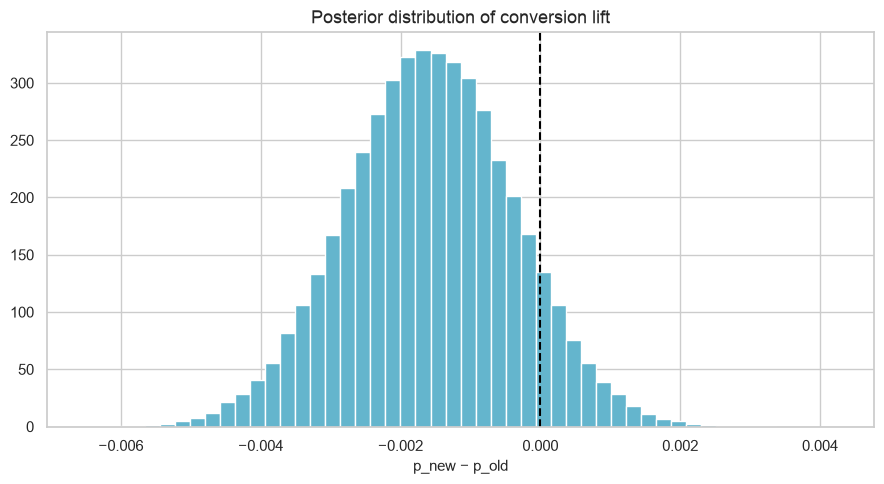

In [13]:
# Uniform Beta(1,1) prior
post_c = stats.beta(1 + conv_control, 1 + (n_control - conv_control))
post_t = stats.beta(1 + conv_treatment, 1 + (n_treatment - conv_treatment))
mc = 100_000
draws_c = post_c.rvs(mc, random_state=RNG)
draws_t = post_t.rvs(mc, random_state=RNG)
p_new_better = float(np.mean(draws_t > draws_c))
p_old_better = float(np.mean(draws_c > draws_t))
lift_draws = draws_t - draws_c
bayes_ci = np.quantile(lift_draws, [0.025, 0.975])

print("=== Bayesian Beta–Binomial (uniform prior) ===")
print(f"P(p_new > p_old | data) = {p_new_better:.4%}")
print(f"P(p_old > p_new | data) = {p_old_better:.4%}")
print(f"Posterior mean lift: {lift_draws.mean():.6f}")
print(f"Central 95% posterior interval for lift: [{bayes_ci[0]:.6f}, {bayes_ci[1]:.6f}]")

fig, ax = plt.subplots()
ax.hist(lift_draws, bins=50, color="#64B5CD", edgecolor="white", density=True)
ax.axvline(0, color="black", ls="--")
ax.set_xlabel("p_new − p_old")
ax.set_title("Posterior distribution of conversion lift")
plt.tight_layout()
plt.show()

## Part 7 — Production decision scorecard

Gates inspired by trustworthy experimentation practice:

1. **Data quality** cleaned (mismatches/dups handled)  
2. **SRM** not severe  
3. **Primary OEC** statistically significant *and* in the desired direction  
4. **Practical significance** (estimate and/or CI outside the indifference band)  
5. **Power** adequate for the business MDE (else EXTEND only if that is the gap)

Default outcome for a well-powered null: **HOLD**.

In [14]:
improved = abs_diff > 0
meaningful_lift = significant and abs_diff >= PRACTICAL_ABS_PP
quality_ok = n_mismatch >= 0  # always true; we cleaned
trust_ok = not srm_severe

if not trust_ok:
    recommendation = "HOLD"
    rec_reason = (
        "Severe SRM / trustworthiness failure — do not ship on this experiment until diagnosed."
    )
elif meaningful_lift and trust_ok:
    recommendation = "SHIP"
    rec_reason = (
        f"Statistically significant improvement ≥ {PRACTICAL_ABS_PP*100:.2f} pp and SRM not severe."
    )
elif significant and not improved:
    recommendation = "HOLD"
    rec_reason = "New creative is significantly worse or not better; keep the old campaign page."
elif underpowered_for_mde:
    recommendation = "EXTEND"
    rec_reason = (
        f"Non-decisive for a +{MDE_ABS_PP*100:.2f} pp MDE with power {pwr_mde.power:.1%} < {POWER_TARGET:.0%}."
    )
else:
    recommendation = "HOLD"
    rec_reason = (
        "No significant improvement; experiment already powered for a business-relevant +1 pp MDE. "
        "Keep the old campaign creative."
    )

# Scorecard table
scorecard = pd.DataFrame(
    [
        {"gate": "Schema validation", "status": "PASS", "detail": "Required columns/values present"},
        {
            "gate": "Exposure cleaning",
            "status": "PASS",
            "detail": f"Dropped {n_mismatch:,} mismatches; de-duped to {n_after_dedup:,} users",
        },
        {
            "gate": "SRM (not severe)",
            "status": "PASS" if trust_ok else "FAIL",
            "detail": f"p={srm_p:.3g}, imbalance={abs_imbalance_pp:.4f}pp",
        },
        {
            "gate": f"Primary OEC z-test (α={ALPHA})",
            "status": "SIGNIFICANT" if significant else "NOT SIGNIFICANT",
            "detail": f"z={zstat:.3f}, p={pval:.6f}, diff={abs_diff*100:.3f}pp",
        },
        {
            "gate": "Practical significance",
            "status": "YES" if meaningful_lift else "NO",
            "detail": f"band=±{PRACTICAL_ABS_PP*100:.2f}pp; CI=[{ci_low*100:.3f}, {ci_high*100:.3f}]pp",
        },
        {
            "gate": f"Power for +{MDE_ABS_PP*100:.0f}pp MDE ≥ {POWER_TARGET:.0%}",
            "status": "PASS" if not underpowered_for_mde else "FAIL",
            "detail": f"power={pwr_mde.power:.1%}, n/arm={actual_n_per_arm:,} (need ~{n_for_mde:,.0f})",
        },
        {
            "gate": "Country-adjusted OR ~ 1",
            "status": "CONSISTENT NULL" if abs(or_ab_m2 - 1) < 0.05 else "MATERIAL OR",
            "detail": f"OR={or_ab_m2:.4f}, p={pval_ab_m2:.6f}",
        },
        {
            "gate": "Bayesian P(new > old)",
            "status": f"{p_new_better:.1%}",
            "detail": "Uniform Beta–Binomial secondary check",
        },
        {
            "gate": "Segment FDR discoveries",
            "status": str(int(seg["sig_fdr_bh"].sum())),
            "detail": "Countries significant after BH-FDR",
        },
        {"gate": "RECOMMENDATION", "status": recommendation, "detail": rec_reason},
    ]
)
display(scorecard)

print("=" * 72)
print("PRODUCTION MANAGER SUMMARY")
print("=" * 72)
print(f"Data path: {load_path_used.splitlines()[0]}")
print(f"Cleaned users: {n_after_dedup:,}  |  merge n: {n_after_merge:,}")
print(f"Old page: {p_control:.4%} (n={n_control:,})  |  New page: {p_treatment:.4%} (n={n_treatment:,})")
print(f"Lift: {abs_diff*100:+.4f} pp  |  relative {rel_diff:+.2%}")
print(f"z={zstat:.4f}, p={pval:.6f}, 95% CI diff=[{ci_low:.6f}, {ci_high:.6f}]")
print(f"Bootstrap 95% CI: [{boot_ci[0]:.6f}, {boot_ci[1]:.6f}]")
print(f"OR unadj={or_ab_m1:.4f}, OR country-adj={or_ab_m2:.4f} (p={pval_ab_m2:.6f})")
print(f"SRM χ² p={srm_p:.6g}, imbalance={abs_imbalance_pp:.4f}pp, severe={srm_severe}")
print(f"Power @ +{MDE_ABS_PP*100:.0f}pp MDE: {pwr_mde.power:.1%}  |  Bayesian P(new>old)={p_new_better:.2%}")
print(f"RECOMMENDATION: {recommendation}")
print(f"Reason: {rec_reason}")
print()
print(
    f"Plain language: On {n_after_dedup:,} cleaned users, the new marketing-campaign landing page "
    f"converted at {p_treatment:.2%} vs {p_control:.2%} for the old page "
    f"({abs_diff*100:+.3f} pp). The two-proportion test is {'' if significant else 'not '}"
    f"significant at α={ALPHA} (p={pval:.3f}). Country-adjusted odds ratio is {or_ab_m2:.3f}. "
    f"Power for a +{MDE_ABS_PP*100:.0f} pp lift is ~{pwr_mde.power:.0%}. "
    f"Bayesian P(new better)≈{p_new_better:.0%}. **Decision: {recommendation}.**"
)
print()
print("Limitations:")
print("  - Educational public dataset; treat as methodology portfolio, not a live product claim.")
print("  - Mismatched exposures dropped; ITT-style alternatives not primary.")
print("  - MDE and practical band are transparent business benchmarks (not historically pre-registered here).")
print("  - Bayesian analysis uses a weakly informative uniform prior.")
print("  - No CUPED variance reduction (no pre-period covariate in this dataset).")
print("=" * 72)

,gate,status,detail
0,Schema validation,PASS,Required columns/values present
1,Exposure cleaning,PASS,"Dropped 3,893 mismatches; de-duped to 290,584 ..."
2,SRM (not severe),PASS,"p=0.947, imbalance=0.0062pp"
3,Primary OEC z-test (α=0.05),NOT SIGNIFICANT,"z=-1.311, p=0.189883, diff=-0.158pp"
4,Practical significance,NO,"band=±0.50pp; CI=[-0.394, 0.078]pp"
5,Power for +1pp MDE ≥ 80%,PASS,"power=100.0%, n/arm=145,274 (need ~17,209)"
6,Country-adjusted OR ~ 1,CONSISTENT NULL,"OR=0.9852, p=0.191245"
7,Bayesian P(new > old),9.4%,Uniform Beta–Binomial secondary check
8,Segment FDR discoveries,0,Countries significant after BH-FDR
9,RECOMMENDATION,HOLD,No significant improvement; experiment already...


PRODUCTION MANAGER SUMMARY
Data path: raw GitHub URLs
Cleaned users: 290,584  |  merge n: 290,584
Old page: 12.0386% (n=145,274)  |  New page: 11.8808% (n=145,310)
Lift: -0.1578 pp  |  relative -1.31%
z=-1.3109, p=0.189883, 95% CI diff=[-0.003938, 0.000781]
Bootstrap 95% CI: [-0.003973, 0.000769]
OR unadj=0.9851, OR country-adj=0.9852 (p=0.191245)
SRM χ² p=0.946754, imbalance=0.0062pp, severe=False
Power @ +1pp MDE: 100.0%  |  Bayesian P(new>old)=9.39%
RECOMMENDATION: HOLD
Reason: No significant improvement; experiment already powered for a business-relevant +1 pp MDE. Keep the old campaign creative.

Plain language: On 290,584 cleaned users, the new marketing-campaign landing page converted at 11.88% vs 12.04% for the old page (-0.158 pp). The two-proportion test is not significant at α=0.05 (p=0.190). Country-adjusted odds ratio is 0.985. Power for a +1 pp lift is ~100%. Bayesian P(new better)≈9%. **Decision: HOLD.**

Limitations:
  - Educational public dataset; treat as methodology 

## Closing

| Question | Answer from this run |
|---|---|
| Is the experiment trustworthy enough to analyze? | See SRM + cleaning gates |
| Did the new creative win conversion? | See z-test / CI / Bayesian P |
| Is any effect large enough to care about? | Practical band + OR |
| Should we run longer? | Power vs MDE |
| **Ship / hold / extend?** | Scorecard recommendation |

**Production mindset:** a large, clean, well-powered **null** is a successful experiment — it stops a bad or neutral creative from shipping on gut feel.

### References (practice)

- Kohavi, Tang, Xu — *Trustworthy Online Controlled Experiments* (Cambridge)  
- Microsoft Research — diagnosing Sample Ratio Mismatch  
- DoorDash / Eppo / Statsig engineering blogs — SRM as a release gate  
- statsmodels — `proportions_ztest`, `confint_proportions_2indep`, `proportion_confint` (Wilson)  